In [71]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os

In [72]:
# Load image
image_path = "SVD_birds-256-by-256-pixels.png"
img = Image.open(image_path).convert("L")
A = np.array(img, dtype=np.float64)

# implement compress block function
def compress_block(block, k):
    # Apply SVD
    U, S, VT = np.linalg.svd(block, full_matrices=False)

    # keep only top_k SVD
    U_k = U[:, :k]
    S_k = np.diag(S[:k])
    VT_k = VT[:k, :]

    # Reconstruct block
    reconstructed = U_k @ S_k @ VT_k
    return reconstructed

In [73]:
# Apply block-wise SVD to image
def compress_image_blockwise(image, k, block_size=8):
    w, z = image.shape
    compressed = np.zeros_like(image)
    
    for v in range(0, w, block_size):
        for y in range(0, z, block_size):
            block = image[v:v+block_size, y:y+block_size]
            compressed_block = compress_block(block, k)
            compressed[v:v+block_size, y:y+block_size] = compressed_block
    return compressed

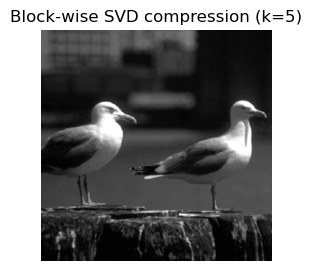

In [74]:
# Run compression
k = 5
compressed_image = compress_image_blockwise(A, k)

# ensure valid grayscale range
compressed_image = np.clip(compressed_image, 0, 255)

plt.figure(figsize=(12, 3))
plt.imshow(compressed_image, cmap='gray')
plt.title(f"Block-wise SVD compression (k={k})")
plt.axis('off')
plt.show()

k | Compression Ratio (64 / 17k)
----------------------------------
1 | 3.76
2 | 1.88
3 | 1.25
4 | 0.94
5 | 0.75
6 | 0.63
7 | 0.54
8 | 0.47


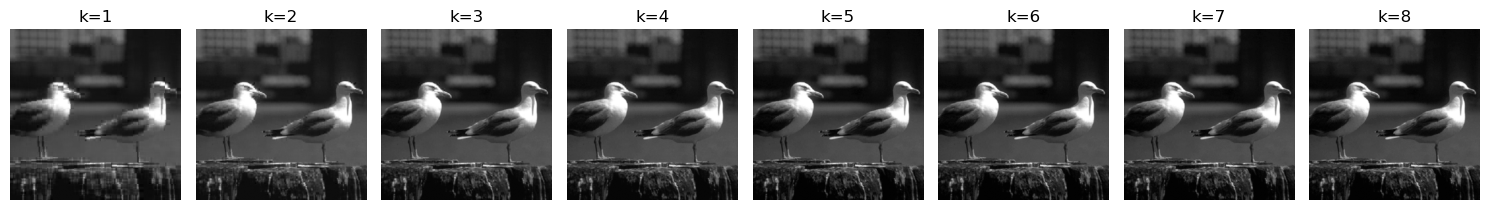


Images saved in folder: k_reconstructed_images


In [77]:
def svd_block_compress(image_path, k_values=[1,2,3,4,5,6,7,8], block_size=8): 
    w, z = A.shape
    assert w % block_size == 0 and z % block_size == 0, \
        "Image dimensions must be divisible by block size."
    
    # Save image files in a folder
    output_dir = "k_reconstructed_images"
    os.makedirs(output_dir, exist_ok=True)

    # run for k = 1 to 8
    print("k | Compression Ratio (64 / 17k)")
    print("----------------------------------")
    
    plt.figure(figsize=(15, 4))
    
    for idx, k in enumerate(k_values):
        
        compressed = np.zeros_like(A)
        
        # Block-wise compression
        for v in range(0, w, block_size):
            for y in range(0, z, block_size):
                block = A[v:v+block_size, y:y+block_size]
                compressed_block = compress_block(block, k)
                compressed[v:v+block_size, y:y+block_size] = compressed_block

        # Compress image
        compressed = np.clip(compressed, 0, 255)
        
        # Save reconstructed image
        save_path = os.path.join(output_dir, f"compressed_k_{k}.png")
        Image.fromarray(compressed.astype(np.uint8)).save(save_path)
        
        # Compute compression ratio
        compression_ratio = 64 / (17 * k)
        print(f"{k} | {compression_ratio:.2f}")
        
        # Plot for k = 1 to 8
        plt.subplot(1, len(k_values), idx+1)
        plt.imshow(compressed, cmap='gray')
        plt.title(f"k={k}")
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print("\nImages saved in folder:", output_dir)

svd_block_compress(
    "SVD_birds-256-by-256-pixels.png",
    k_values=[1,2,3,4,5,6,7,8]
)

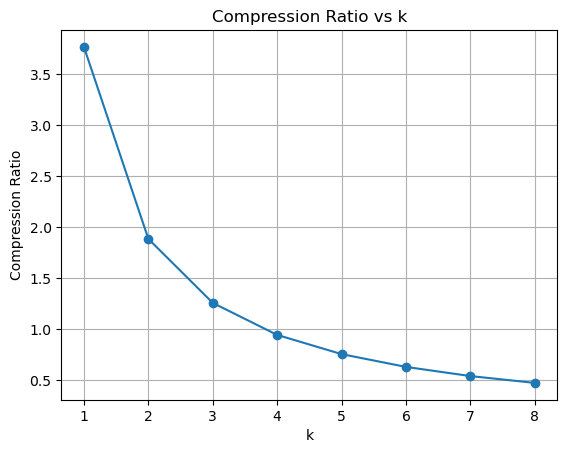

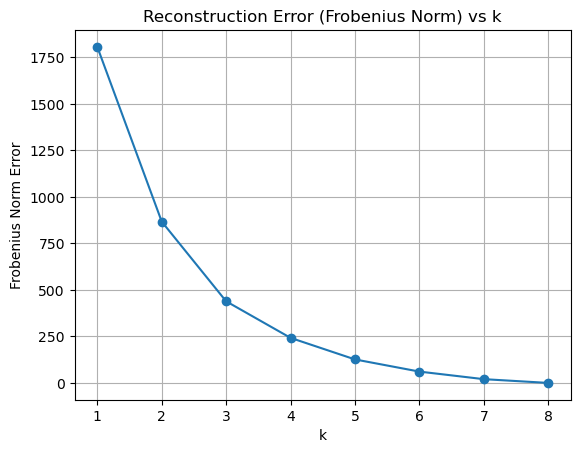

k | PSNR (dB)
----------------
1 | 31.16
2 | 37.53
3 | 43.45
4 | 48.61
5 | 54.27
6 | 60.61
7 | 70.18
8 | 301.25


In [81]:
k_values = list(range(1, 9))

compression_ratios = []
frobenius_errors = []
psnr_values = []

for k in k_values:
    
    compressed = compress_image_blockwise(A, k)
    compressed = np.clip(compressed, 0, 255)
    
    # Compression Ratio
    compression_ratio = 64 / (17 * k)
    compression_ratios.append(compression_ratio)
    
    # Frobenius Norm Error
    fro_error = np.linalg.norm(A - compressed, 'fro')
    frobenius_errors.append(fro_error)
    
    # PSNR
    mse = np.mean((A - compressed) ** 2)
    if mse == 0:
        psnr = float('inf')
    else:
        psnr = 20 * np.log10(255 / np.sqrt(mse))
    psnr_values.append(psnr)


# Compression Ratio vs k

plt.figure()
plt.plot(k_values, compression_ratios, marker='o')
plt.title("Compression Ratio vs k")
plt.xlabel("k")
plt.ylabel("Compression Ratio")
plt.grid(True)
plt.show()


# Frobenius Error vs k

plt.figure()
plt.plot(k_values, frobenius_errors, marker='o')
plt.title("Reconstruction Error (Frobenius Norm) vs k")
plt.xlabel("k")
plt.ylabel("Frobenius Norm Error")
plt.grid(True)
plt.show()


# Print PSNR Values
print("k | PSNR (dB)")
print("----------------")
for k, psnr in zip(k_values, psnr_values):
    print(f"{k} | {psnr:.2f}")

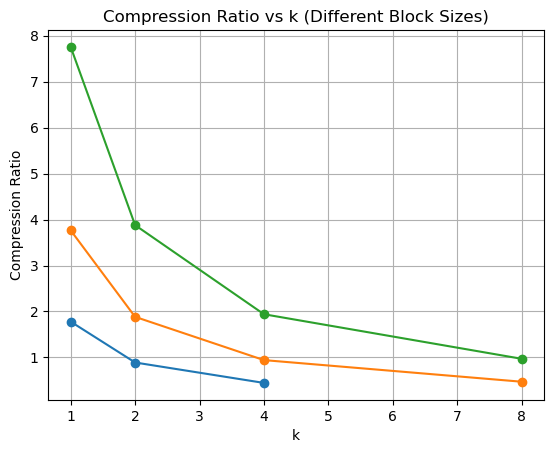

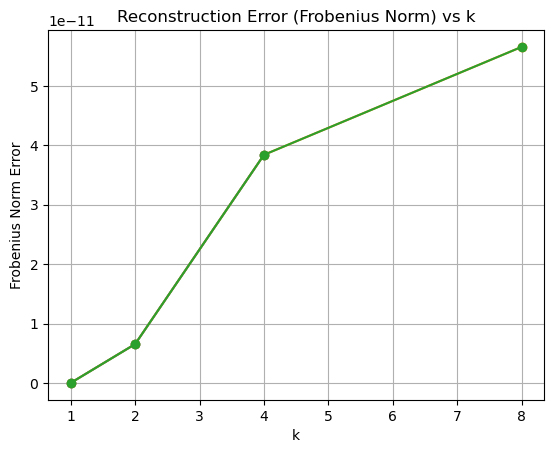

In [87]:
# Experiment with other block sizes
block_sizes = [4, 8, 16]
k_values = [1, 2, 4, 8]

results = {}

for block_size in block_sizes:
    
    compression_ratios = []
    frobenius_errors = []
    
    for k in k_values:
        if k > block_size:
            compression_ratios.append(np.nan)
            frobenius_errors.append(np.nan)
            continue
        
        compressed = compress_image_blockwise(A, block_size, k)
        compressed = np.clip(compressed, 0, 255)
        
        # Compression Ratio formula: n^2 / (k(2n+1))
        n = block_size
        compression_ratio = (n**2) / (k * (2*n + 1))
        compression_ratios.append(compression_ratio)
        
        # Frobenius Reconstruction Error
        error = np.linalg.norm(A - compressed, 'fro')
        frobenius_errors.append(error)
    
    results[block_size] = (compression_ratios, frobenius_errors)

# Plot Compression Ratio
plt.figure()
for block_size in block_sizes:
    plt.plot(k_values, results[block_size][0], marker='o')

plt.title("Compression Ratio vs k (Different Block Sizes)")
plt.xlabel("k")
plt.ylabel("Compression Ratio")
plt.grid(True)
plt.show()

# Plot Reconstruction Error
plt.figure()
for block_size in block_sizes:
    plt.plot(k_values, results[block_size][1], marker='o')

plt.title("Reconstruction Error (Frobenius Norm) vs k")
plt.xlabel("k")
plt.ylabel("Frobenius Norm Error")
plt.grid(True)
plt.show()